In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anantsinghal786/almost-million-songs-dataset-2025-16-features")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'almost-million-songs-dataset-2025-16-features' dataset.
Path to dataset files: /kaggle/input/almost-million-songs-dataset-2025-16-features


In [ ]:
import pandas as pd

df = pd.read_csv("/content/tracks.csv")

print(df.head())

                 track_id                                        genres  \
0  07vS8obfeZbr8H4MgQfXR7       ['indie pop', 'la indie', 'pov: indie']   
1  1PEqh7awkpuepLBSq8ZwqD                    ['lilith', 'new wave pop']   
2  7E8pPgBY84oDaXRcqODavR  ['deep groove house', 'house', 'tech house']   
3  0Atml4huw4Fgyk6YSHiK4M                                            []   
4  4WYDmIZrwxBHdBYdvi5oQO                ['chill lounge', 'deep chill']   

     track_artists    tempo  energy  key  popularity  mode  time_signature  \
0  Phoebe Bridgers   97.129   0.123  7.0         0.0   1.0             4.0   
1              NaN  103.773   0.453  5.0        71.0   1.0             4.0   
2              NaN  122.030   0.878  9.0         0.0   0.0             4.0   
3              NaN   84.099   0.484  7.0         0.0   1.0             4.0   
4              NaN  156.017   0.447  0.0         7.0   1.0             4.0   

   speechiness  danceability  valence  acousticness  liveness  \
0       0.0407 

In [ ]:
rows, cols = df.shape
print("Number of rows:", rows)
print("Number of columns:", cols)

Number of rows: 899702
Number of columns: 16


In [ ]:
print(df.shape)
print(df.info())

(899702, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899702 entries, 0 to 899701
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          899702 non-null  object 
 1   genres            892516 non-null  object 
 2   track_artists     99943 non-null   object 
 3   tempo             899224 non-null  float64
 4   energy            899224 non-null  float64
 5   key               899224 non-null  float64
 6   popularity        899701 non-null  float64
 7   mode              899224 non-null  float64
 8   time_signature    899224 non-null  float64
 9   speechiness       899224 non-null  float64
 10  danceability      899224 non-null  float64
 11  valence           899224 non-null  float64
 12  acousticness      899224 non-null  float64
 13  liveness          899224 non-null  float64
 14  instrumentalness  899224 non-null  float64
 15  name              899215 non-null  object 
dtypes: floa

BASIC CLEANING

In [ ]:
df = df.drop_duplicates()


print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
track_id                 0
genres                7186
track_artists       799759
tempo                  478
energy                 478
key                    478
popularity               1
mode                   478
time_signature         478
speechiness            478
danceability           478
valence                478
acousticness           478
liveness               478
instrumentalness       478
name                   487
dtype: int64


In [ ]:
import numpy as np
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [ ]:
df = df.dropna()

print("Shape after dropping missing values:", df.shape)

Shape after dropping missing values: (99140, 16)


In [ ]:

numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.columns)

Index(['tempo', 'energy', 'key', 'popularity', 'mode', 'time_signature',
       'speechiness', 'danceability', 'valence', 'acousticness', 'liveness',
       'instrumentalness'],
      dtype='object')


In [ ]:
target = "popularity"

X = numeric_df.drop(columns=[target])
y = numeric_df[target]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CORRELATION ANALYSIS

In [ ]:
corr = numeric_df.corr()["popularity"].sort_values(ascending=False)

print("\nCorrelation with Popularity:")
print(corr)


Correlation with Popularity:
popularity          1.000000
danceability        0.121802
energy              0.118687
valence             0.063087
time_signature      0.044119
speechiness         0.041642
tempo               0.023279
key                 0.005384
liveness            0.000929
mode               -0.011267
acousticness       -0.130494
instrumentalness   -0.179766
Name: popularity, dtype: float64


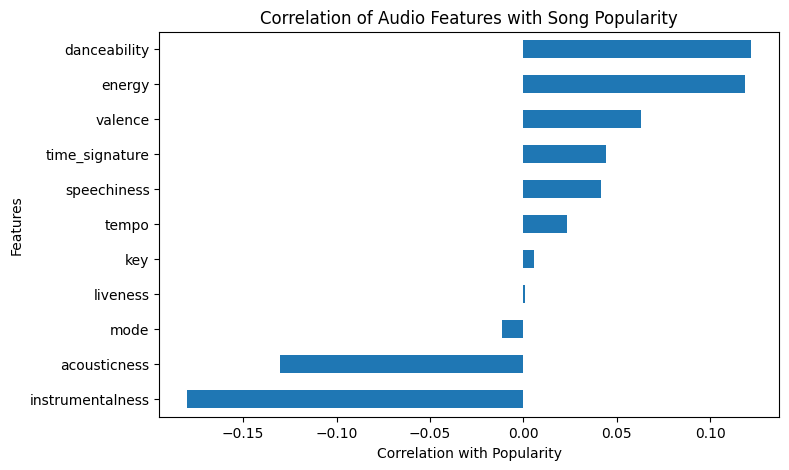

In [ ]:

numeric_df = df.select_dtypes(include=np.number)


corr = numeric_df.corr()


target_corr = corr["popularity"].drop("popularity").sort_values()


plt.figure(figsize=(8,5))
target_corr.plot(kind="barh")

plt.xlabel("Correlation with Popularity")
plt.ylabel("Features")
plt.title("Correlation of Audio Features with Song Popularity")


plt.savefig("popularity_correlation.pdf", bbox_inches="tight")

plt.show()

Training and testing the model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Re-create df with all preprocessing steps for robustness
df = pd.read_csv("/content/tracks.csv")
df = df.drop_duplicates()
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df = df.dropna()


features = [
    "valence",
    "energy",
    "danceability",
    "tempo",
    "key",
    "liveness",
    "speechiness"
]
target = "popularity"


df_model = df[features + [target]].dropna()


numerical_features_for_scaling = [f for f in features if f != 'genres']
X = df_model[numerical_features_for_scaling]
y = df_model[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_scaled, y)

importance = pd.DataFrame({
    "Feature": numerical_features_for_scaling,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)


importance.to_csv("feature_importance.csv", index=False)

        Feature  Importance
1        energy    0.167627
3         tempo    0.160032
0       valence    0.153764
6   speechiness    0.149806
2  danceability    0.149030
5      liveness    0.145435
4           key    0.074307


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df.to_csv("pca_features.csv", index=False)

Explained Variance Ratio: [0.29159802 0.16108744]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (79312, 7)
Test shape: (19828, 7)


In [ ]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (69398, 7)
Validation: (14871, 7)
Test: (14871, 7)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


model = RandomForestRegressor(n_estimators=100, random_state=42)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)

Train shape: (79312, 7)
Test shape: (19828, 7)


Evaluation Metrics

In [ ]:


# Predict on test set
y_pred = model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))


mae = mean_absolute_error(y_test, y_pred)


r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print("--------------------------")
print("RMSE:", rmse)
print("MAE :", mae)
print("R² Score:", r2)

Model Evaluation Metrics:
--------------------------
RMSE: 20.003244316644576
MAE : 17.007048736816675
R² Score: 0.010482446031425674


In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

RQ -1 FEATURE IMPORTANCE ON POPULARITY ,,To what extent do audio features such as energy, danceability, loudness, tempo, and valence influence song popularity?


📊 Top Features:
         Feature  Importance
1        energy    0.168165
3         tempo    0.159613
0       valence    0.154404
2  danceability    0.149504
6   speechiness    0.149168
5      liveness    0.145468
4           key    0.073679


<Figure size 800x500 with 0 Axes>

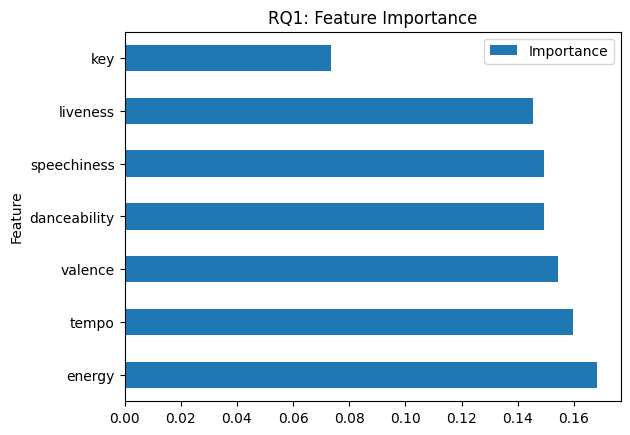

In [ ]:

plt.figure(figsize=(8,5))
importance.head(10).plot(kind="barh", x="Feature", y="Importance")
print("\n📊 Top Features:\n", importance.head(10))

plt.title("RQ1: Feature Importance")
plt.savefig("RQ1_feature_importance.pdf", bbox_inches="tight")
plt.show()